<a href="https://colab.research.google.com/github/gcardas/Machine-learning/blob/vscode/Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A Hands-On Introduction to Data Analytics for Biomedical Research

## Importing the Proper Libraries and Example Dataset

New mark down

In this tutorial, we will use the following libraries: numpy, pandas, matplotliadb **ANY OTHERS (?)**
These libraries are preinstalled in google colab and can be imported with the following code:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact
from PIL import Image
import seaborn as sns

To use the exampledata set from UC Irvine's Machine Learning Repository, we will also need to install the ucimlrepo library

In [ ]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
# comment

## Download Dataset

For this example we will be loading in a myocardial infarction complication dataset from UC Irvines's Machine Learning Repository. The dataset can be loaded and information about the dataset can be found with the following code

In [ ]:
myocardial_infarction_complications = fetch_ucirepo(id=579)

X = myocardial_infarction_complications.data.features # Split features vs predictors
y = myocardial_infarction_complications.data.targets  # Split features vs predictors
X = X.fillna(0) # This can be changed based on how we handle missing data (@Kate)
y = y.fillna(0)

# asdasd

print("The name of this dataset is {}".format(myocardial_infarction_complications.metadata.name))
print("The number of features in this dataset is {}".format(myocardial_infarction_complications.metadata.num_features))
print("The number of instances in this dataset is {}".format(myocardial_infarction_complications.metadata.num_instances))
print("There are {} possible targets for this dataset and they are {}\n".format(len(myocardial_infarction_complications.metadata.target_col),myocardial_infarction_complications.metadata.target_col))
print("Additional Information about this dataset \n{}".format(myocardial_infarction_complications.metadata.additional_info.summary))


The name of this dataset is Myocardial infarction complications
The number of features in this dataset is 111
The number of instances in this dataset is 1700
There are 12 possible targets for this dataset and they are ['FIBR_PREDS', 'PREDS_TAH', 'JELUD_TAH', 'FIBR_JELUD', 'A_V_BLOK', 'OTEK_LANC', 'RAZRIV', 'DRESSLER', 'ZSN', 'REC_IM', 'P_IM_STEN', 'LET_IS']

Additional Information about this dataset 
Problems of real-life complexity are needed to test and compare various data mining and pattern recognition methods. The proposed database can be used to solve two practically important problems: predicting complications of Myocardial Infarction (MI) based on information about the patient (i) at the time of admission and (ii) on the third day of the hospital period. Another important group of tasks is phenotyping of disease (cluster analysis), dynamic phenotyping (filament extraction and identification of disease trajectories) and visualisation (disease mapping). 
MI is one of the most cha

In addition, you may wish to save the figures generated in this code to your google drive. To do so, you will need to mount your google drive and specify the path for the folder which you would like to save images in

# Dimensionality Reduction

In [ ]:
##Extracting the independent variable types to remove categorical features

#access variable information and filter for intedpenent features
variables=myocardial_infarction_complications.variables.loc[:,["name","type","role"]]
variables=variables[variables.role == "Feature"]

#summary table of variable types in the dataset
variables.type.value_counts()

#remove categorical variables prior to dimensionality reduction, as their distance values may not be mathematically meaningful
variables=variables[variables.type!="Categorical"]
noCats=X.loc[:,list(set(X.columns)&set(variables.name))]

print("Dimensions of non-categorical feature data: ", noCats.shape)

Dimensions of non-categorical feature data:  (1700, 95)


The output of PCA retains the same dimensionality as the original dataset:  (1700, 26)

However, instead of 95 named variables, each of the 1700 observations is defined by 95 orthogonal principal components.

The first principal component represents the axis of greatest variation in the data, with each subsequent component capturing less than the one before it.

The extent of this captured variance can be visualized using a scree plot, shown below.



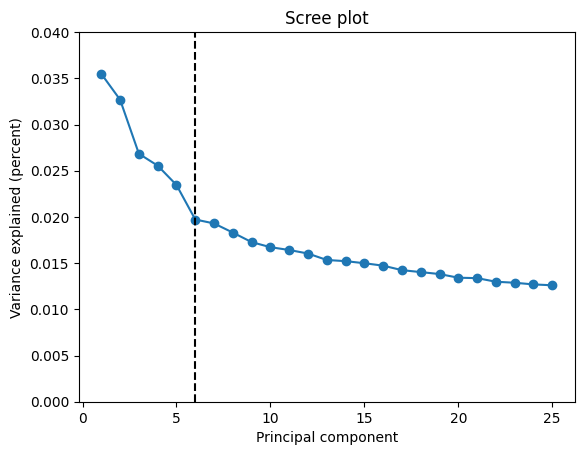


Total variance explained by first 25 principal components: 44.81%

Total variance explained by first 6 principal components: 16.37%


In [ ]:
##run PCA on the dataset
# already loaded dependencies above
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


#Center and scale data using StandardScaler function
scaled_noCats = StandardScaler().fit_transform(noCats)

#Run PCA on the scaled data
pca=PCA(n_components=26)
pca_embedding=pca.fit_transform(scaled_noCats)


print("The output of PCA retains the same dimensionality as the original dataset: ",pca_embedding.shape)
print("\nHowever, instead of 95 named variables, each of the 1700 observations is defined by 95 orthogonal principal components.")
print("\nThe first principal component represents the axis of greatest variation in the data, with each subsequent component capturing less than the one before it.")
print("\nThe extent of this captured variance can be visualized using a scree plot, shown below.\n")



#Select number of PCs to include on scree plot (up to 95), which plots the principal components against their corresponding eigenvalues.
#Each eigenvalue is proportional to the dataset variance explained by its respective principal component.

#number of components to plot
n_comp=25

#Cutoff variable to select "elbow" in scree plot,
cutoff=6


plt.plot(np.array(range(1,n_comp+1)),pca.explained_variance_ratio_[0:n_comp])
plt.scatter(np.array(range(1,n_comp+1)),pca.explained_variance_ratio_[0:n_comp])

plt.title("Scree plot")
plt.xlabel("Principal component")
plt.ylabel("Variance explained (percent)")
plt.ylim(0,0.04)
plt.axvline(x=cutoff,color='k',linestyle='--')
plt.savefig("NonCat_data_PCA_scree.png")
plt.show()
# plt.savefig("NonCat_data_PCA_scree.png")

print(f"\nTotal variance explained by first {n_comp} principal components: {pca.explained_variance_ratio_[0:n_comp].sum() * 100:.2f}%")
print(f"\nTotal variance explained by first {cutoff} principal components: {pca.explained_variance_ratio_[0:cutoff].sum() * 100:.2f}%")


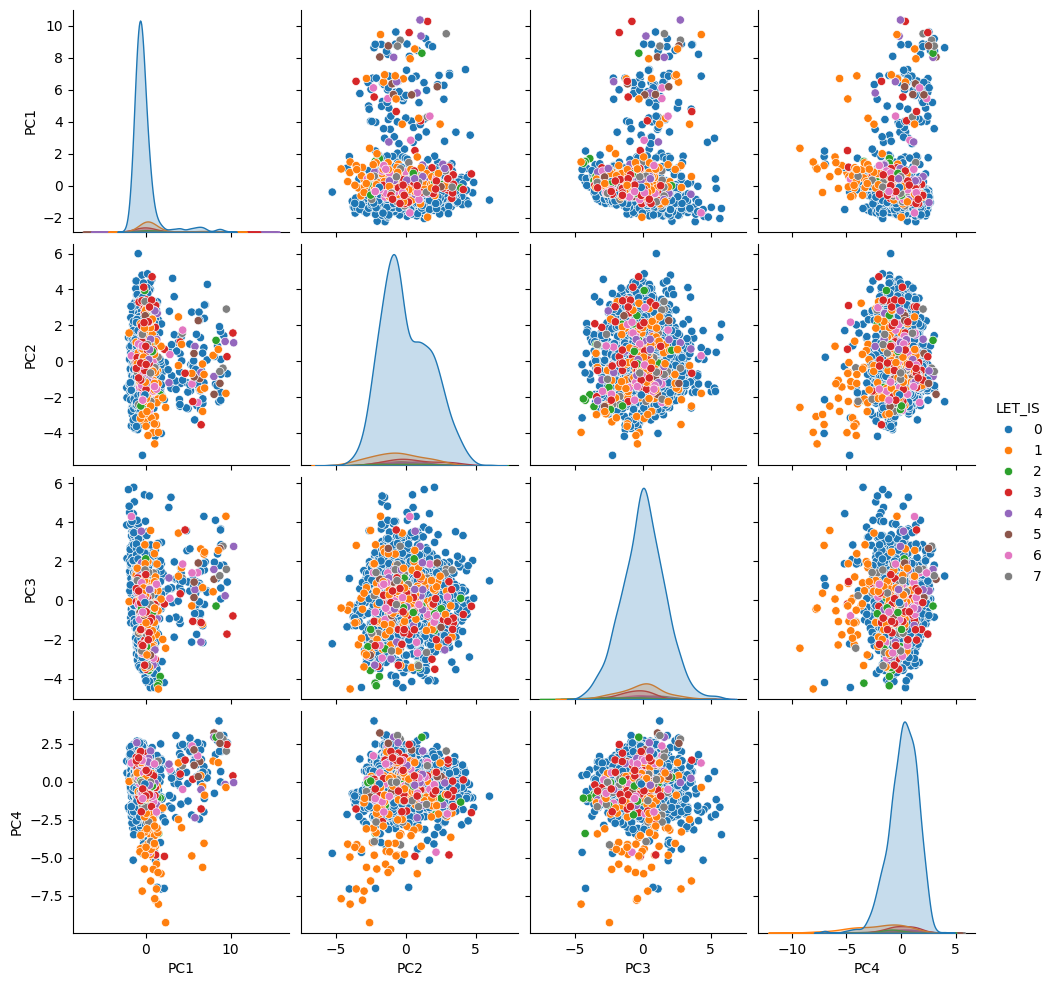

In [ ]:
#Convert PCA embeddings matrix to pandas DataFrame and add patient lethal outcome column (LET_IS)
pca_embedding=pd.DataFrame(pca_embedding).iloc[:,0:4]
col_names=list()

for i in range(pca_embedding.shape[1]):
  col_names.append("PC"+str(i+1))

pca_embedding.columns=col_names
pca_embedding["LET_IS"]=y.LET_IS.astype("category")


##Plot first four principal components against each other in grid view

import seaborn as sns

sns_plot=sns.pairplot(pca_embedding,hue="LET_IS")
fig = sns_plot.fig
fig.savefig("PCA_pairplot.png")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


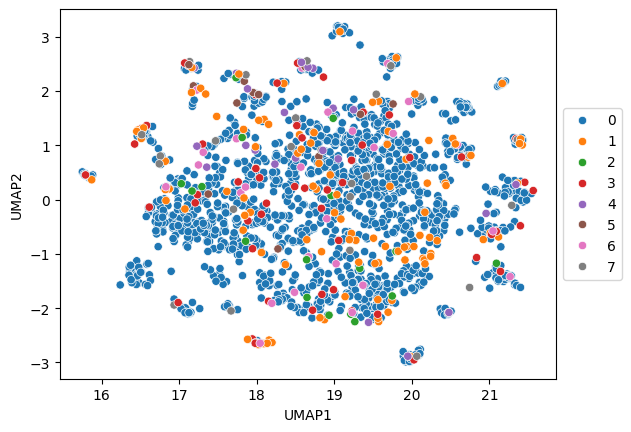

In [ ]:
#Plotting UMAP of data with default parameters
# !pip install umap-learn
import umap.umap_ as umap

reducer=umap.UMAP(random_state=10,n_neighbors=250)
umap_embedding = reducer.fit_transform(scaled_noCats)
umap_embedding=pd.DataFrame(data=umap_embedding)
umap_embedding.columns=["UMAP1","UMAP2"]
umap_embedding["LET_IS"]=y.LET_IS.astype("category")

g=sns.scatterplot(data=umap_embedding,x="UMAP1",y="UMAP2",hue="LET_IS")
g.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for p

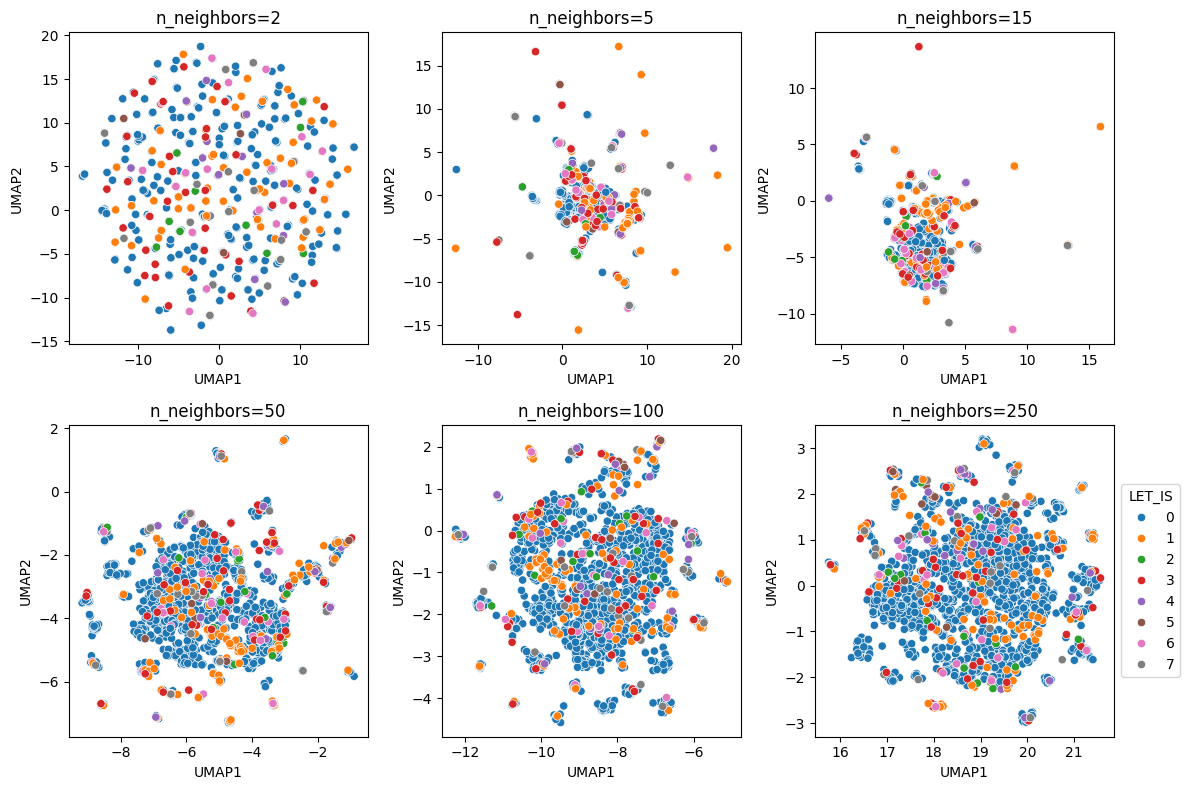

In [ ]:
#Adjusting n_neighbors parameter to alter UMAP output
#Cannot figure out why additional 1 is being added to the legend
i=1
ncol=3
nrow=2
plt.figure(figsize=(12, 8))

for n in [2,5,15,50,100,250]:
  plt.subplot(nrow, ncol, i)
  reducer=umap.UMAP(n_neighbors=n,random_state=10)
  umap_embedding = reducer.fit_transform(scaled_noCats)
  umap_embedding=pd.DataFrame(data=umap_embedding)
  umap_embedding.columns=["UMAP1","UMAP2"]
  umap_embedding["LET_IS"]=y.LET_IS.astype("category")
  sns.scatterplot(data=umap_embedding,x="UMAP1",y="UMAP2",hue="LET_IS").set(title=f"n_neighbors={n}")
  plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),ncol=1,title="LET_IS")
  if i!=6:
    plt.legend().remove()
  i+=1

plt.tight_layout()
plt.savefig('UMAP_nneighbors.png')
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),ncol=1,title="LET_IS")
plt.show()

# plt.savefig('UMAP_nneighbors.png')

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


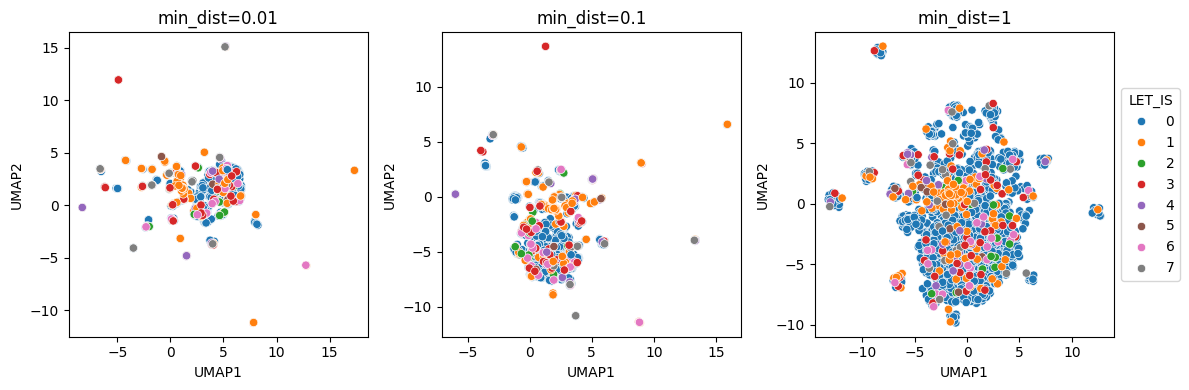

In [ ]:
#Adjusting min_dist parameter to alter UMAP output
i=1
ncol=3
nrow=1
plt.figure(figsize=(12, 4))

for n in [0.01,0.1,1]:
  plt.subplot(nrow, ncol, i)
  reducer=umap.UMAP(min_dist=n,random_state=10)
  umap_embedding = reducer.fit_transform(scaled_noCats)
  umap_embedding=pd.DataFrame(data=umap_embedding)
  umap_embedding.columns=["UMAP1","UMAP2"]
  umap_embedding["LET_IS"]=y.LET_IS.astype("category")
  sns.scatterplot(data=umap_embedding,x="UMAP1",y="UMAP2",hue="LET_IS").set(title=f"min_dist={n}")
  plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),ncol=1,title="LET_IS")
  if i!=3:
    plt.legend().remove()
  i+=1

plt.tight_layout()
plt.savefig('UMAP_mindist.png')
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),ncol=1,title="LET_IS")
plt.show()


# plt.savefig('UMAP_mindist.png')

In [ ]:
import os
print( os.getcwd() )
print( os.listdir() )

from google.colab import files
# files.download('NonCat_data_PCA_scree.png')
# files.download('PCA_pairplot.png')
# files.download('UMAP_nneighbors.png')
# files.download('UMAP_mindist.png' )

/content
['.config', 'NonCat_data_PCA_scree.png', 'UMAP_nneighbors.png', 'UMAP_mindist.png', 'PCA_pairplot.png', 'sample_data']


# Imputing Missing Data



Before imputing missing data, we first need to compute the percent of mssing data for each variable.

In [ ]:
myocardial_infarction_complications = fetch_ucirepo(id=579)
X = myocardial_infarction_complications.data.features # Split features vs predictors

## Visualize Missing Data

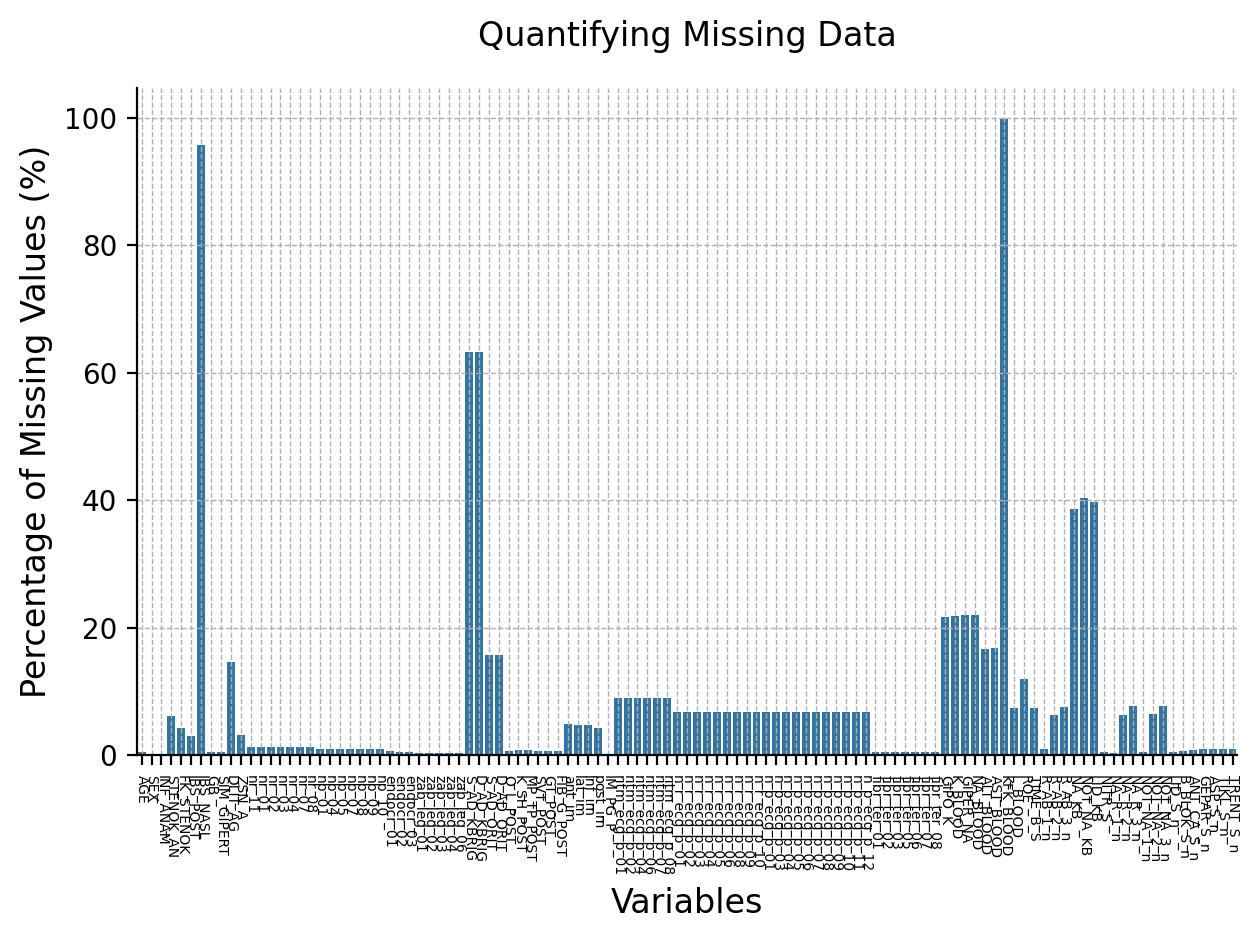

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate percentage of missing data for each variable
percent_missing = X.isnull().mean() * 100  # Scale to percentage

# Set up the figure
fig, ax = plt.subplots(dpi=200)
sns.barplot(x=percent_missing.index,
            y=percent_missing.values,
            ax=ax
            )

# Add styling and labels
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.tick_params(axis='x', labelsize=5, rotation=-90)
ax.set_title('Quantifying Missing Data', fontsize=12, pad=15)
ax.set_ylabel('Percentage of Missing Values (%)', fontsize=12)
ax.set_xlabel('Variables', fontsize=12)

# Improve layout, remove borders, save, and display
plt.tight_layout()
sns.despine()
plt.savefig('missing-data.png', bbox_inches='tight')
plt.show()


## Naive Repalcement of Missing Data

In [ ]:
X = X.fillna(0) # This can be changed based on how we handle missing data (@Kate)
y = y.fillna(0)

## SVD Guided Replacement of Missing Data

In [ ]:
import numpy as np
import pandas as pd

def svd_impute(data):
    nan_mask = np.isnan(data)
    filled_data = data.copy()

    # Perform an initial guess for missing values using column means
    col_means = np.nanmean(filled_data, axis=0)
    filled_data[nan_mask] = np.take(col_means, np.where(nan_mask)[1])

    # Set a convergence threshold and provide a maximum for iterations
    threshold = 1e-5
    max_iterations = 100
    prev_filled_data = None

    for _ in range(max_iterations):
        # Perform SVD on filled data
        U, s, Vt = np.linalg.svd(filled_data, full_matrices=False)

        # Select a number of singular values to use for reconstruction
        # In this case, it's the original number of singular values; you might wish to reduce it
        S = np.diag(s)

        # Reconstruct the complete matrix
        reconstructed_data = U.dot(S).dot(Vt)

        # Only update missing data values
        filled_data[nan_mask] = reconstructed_data[nan_mask]

        # Check for convergence by calculating Frobenius norm, a way to quantify change between iterations
        if prev_filled_data is not None and np.linalg.norm(filled_data - prev_filled_data, ord='fro') < threshold:
            break

        prev_filled_data = filled_data.copy()

    return filled_data

# Assume 'dataset' is a pandas DataFrame with missing values represented by np.nan
# Impute them using our custom SVD impute function
imputed_data = svd_impute(X.to_numpy())

# Convert the numpy array back to a pandas DataFrame
imputed_dataset = pd.DataFrame(imputed_data) #, columns=dataset.columns, index=dataset.index)

# Show the first few rows of the imputed dataset
print(imputed_dataset.head())


    0    1    2    3    4    5    6    7    8    9    ...  101  102  103  104  \
0  77.0  1.0  2.0  1.0  1.0  2.0  0.0  3.0  0.0  7.0  ...  0.0  0.0  0.0  1.0   
1  55.0  1.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  1.0  0.0  0.0  1.0   
2  52.0  1.0  0.0  0.0  0.0  2.0  0.0  2.0  0.0  2.0  ...  3.0  2.0  2.0  1.0   
3  68.0  0.0  0.0  0.0  0.0  2.0  0.0  2.0  0.0  3.0  ...  0.0  0.0  0.0  0.0   
4  60.0  1.0  0.0  0.0  0.0  2.0  0.0  3.0  0.0  7.0  ...  0.0  0.0  0.0  0.0   

   105  106  107  108  109  110  
0  0.0  0.0  1.0  1.0  0.0  0.0  
1  0.0  1.0  1.0  1.0  0.0  1.0  
2  1.0  0.0  1.0  1.0  0.0  0.0  
3  0.0  1.0  1.0  1.0  0.0  0.0  
4  0.0  1.0  0.0  1.0  0.0  1.0  

[5 rows x 111 columns]


## Soft Impute Guided Replacement of Missing Data

In [ ]:
# Install dependencies
!pip install fancyimpute

# Import necessary libraries
import requests
import pandas as pd
from fancyimpute import SoftImpute
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# Download the CSV file from the URL
csv_url = "https://archive.ics.uci.edu/static/public/579/data.csv"
response = requests.get(csv_url)
response.raise_for_status() # Raises an HTTPError for bad responses

# Load the data into a pandas DataFrame
from io import StringIO
data = pd.read_csv(StringIO(response.text), sep=',')
print("Original Data:")
print(data.head())

# Define categorical columns and convert them to categorical type
categorical_columns = ['ID', 'AGE', 'SEX', 'INF_ANAM', 'STENOK_AN', 'FK_STENOK',
                       'IBS_POST', 'IBS_NASL', 'GB', 'SIM_GIPERT', 'JELUD_TAH',
                       'FIBR_JELUD', 'A_V_BLOK', 'OTEK_LANC', 'RAZRIV', 'DRESSLER',
                       'ZSN', 'REC_IM', 'P_IM_STEN', 'LET_IS']
data[categorical_columns] = data[categorical_columns].astype('category')

# Apply OneHotEncoder to the categorical columns
encoder = OneHotEncoder(sparse_output=False, drop='first')
data_encoded = encoder.fit_transform(data[categorical_columns])
encoded_feature_names = encoder.get_feature_names_out(categorical_columns)
data_encoded_df = pd.DataFrame(data_encoded, columns=encoded_feature_names, index=data.index)
print("Encoded Categorical Data:")
print(data_encoded_df.head())

# Scale the numerical data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data.drop(columns=categorical_columns))

# Combine scaled numerical data and encoded categorical data
data_prepared = pd.concat([pd.DataFrame(data_scaled, index=data.index, columns=data.drop(columns=categorical_columns).columns),
                           data_encoded_df], axis=1)
print("Prepared Data:")
print(data_prepared.head())

# Perform imputation using SoftImpute
soft_impute = SoftImpute()
data_imputed = soft_impute.fit_transform(data_prepared)
print("Imputed Data (Scaled):")
print(pd.DataFrame(data_imputed, columns=data_prepared.columns, index=data_prepared.index).head())

# Rescale the imputed data back to the original scale
data_imputed_original_scale = scaler.inverse_transform(data_imputed[:, :len(data_scaled[0])])
data_combined = pd.concat([pd.DataFrame(data_imputed_original_scale, index=data.index, columns=data.drop(columns=categorical_columns).columns),
                           pd.DataFrame(data_imputed[:, len(data_scaled[0]):], index=data.index, columns=encoded_feature_names)], axis=1)
print("Final Imputed Data:")
print(data_combined.head())

# Save the imputed dataset to a new CSV file
data_combined.to_csv('imputed_data.csv', index=False)

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.4 MB/s eta 0:00:00
  Created wheel for fancyimpute: filename=fancyimpute-0.7.0-py3-none-any.whl size=29879 sha256=7ae4fb5be91eb708e769d11b2322fdeb74f17bd19f334633de357cf2498a1d9c
  Stored in directory: /root/.cache/pip/wheels/df/20/91/e4850b9a31cf660c1bc95515d3bcbc8010e869e5de6d5baf07
  Created wheel for knnimpute: filename=knnimpute-0.1.0-py3-none-any.whl size=11331 sha256=4e73258bf412565834833c6b34770ba5e56931fafca6f974ff6c106d93d4fd94
  Stored in directory: /root/.cache/pip/wheels/89/11/61/aa5a3167bfff49218cd043a73a83034b9eadd858b0059521be
Successfully built fancyimpute knnimpute
Original Data:
   ID   AGE  SEX  INF_ANAM  STENOK_AN  FK_STENOK  IBS_POST  IBS_NASL   GB  \
0   1  77.0    1       2.0        1.0        1.0       2.0       NaN  3.0   
1   2  55.0    1       1.0        0.0        0.0       0.0       0.0  0.0   
2   3  52.0    1     

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[SoftImpute] Max Singular Value of X_init = 104.641296
[SoftImpute] Iter 1: observed MAE=0.005537 rank=180
[SoftImpute] Iter 2: observed MAE=0.005537 rank=180
[SoftImpute] Iter 3: observed MAE=0.005536 rank=180
[SoftImpute] Iter 4: observed MAE=0.005535 rank=180
[SoftImpute] Iter 5: observed MAE=0.005533 rank=179
[SoftImpute] Iter 6: observed MAE=0.005530 rank=179
[SoftImpute] Iter 7: observed MAE=0.005528 rank=179
[SoftImpute] Iter 8: observed MAE=0.005525 rank=179
[SoftImpute] Iter 9: observed MAE=0.005523 rank=179
[SoftImpute] Iter 10: observed MAE=0.005521 rank=179
[SoftImpute] Iter 11: observed MAE=0.005519 rank=179
[SoftImpute] Iter 12: observed MAE=0.005518 rank=179
[SoftImpute] Iter 13: observed MAE=0.005517 rank=179
[SoftImpute] Iter 14: observed MAE=0.005516 rank=179
[SoftImpute] Iter 15: observed MAE=0.005515 rank=179
[SoftImpute] Iter 16: observed MAE=0.005514 rank=179
[SoftImpute] Iter 17: observed MAE=0.005513 rank=179
[SoftImpute] Iter 18: observed MAE=0.005513 rank=179


## Other Considerations

In [ ]:
X.to_numpy()

array([[77.,  1.,  2., ...,  1.,  0.,  0.],
       [55.,  1.,  1., ...,  1.,  0.,  1.],
       [52.,  1.,  0., ...,  1.,  0.,  0.],
       ...,
       [55.,  1.,  3., ...,  1.,  0.,  0.],
       [79.,  0.,  2., ...,  1.,  0.,  0.],
       [63.,  1.,  2., ...,  0.,  0.,  0.]])

Space for data reduction and visualization code

# Training and Evaluating Models


## Model Comparisons

First, we import the necessary libraries. We need Pandas for handling data tables, Matplotlib/Seaborn for the graphs, and Scikit-Learn for the machine learning algorithms.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, make_scorer
from sklearn.model_selection import cross_validate

We create a dictionary called models. This acts as a catalog of the algorithms we want to test.

In [ ]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=1, metric='minkowski'),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(criterion='entropy', splitter='random', max_depth=5, min_samples_leaf=10),
    "Random Forest": RandomForestClassifier(n_estimators=100, criterion='entropy', max_depth=10, min_samples_leaf=1),
    "SVM (Linear)": make_pipeline(StandardScaler(), SVC(max_iter=100000)),
    "Neural Network": MLPClassifier(max_iter=500, random_state=42)
}

Here we are defining the metrics to measure performance

In [ ]:
metrics = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, average='weighted', zero_division=0),
    'recall': make_scorer(recall_score, average='weighted', zero_division=0),
    'f1': make_scorer(f1_score, average='weighted', zero_division=0)
}

This is the main engine. It loops through every model in your dictionary and does the following:

Cross-Validation: It splits the data into 5 folds and tests the model 5 times.

Reporting: It prints the average accuracy and the standard deviation (stability).

Data Processing: It converts the complex dictionary of results into a flat Pandas DataFrame (using .explode) so it can be graphed.

Plotting: It draws a bar chart with error bars (the black lines on top).

Short error bars = The model is stable and reliable.

Tall error bars = The model performs wildly differently depending on which data chunk it sees.

Comparing models using with 5-Fold Cross-Validation...
----------------------------------------
KNN: 0.8294 (std: 0.0089)


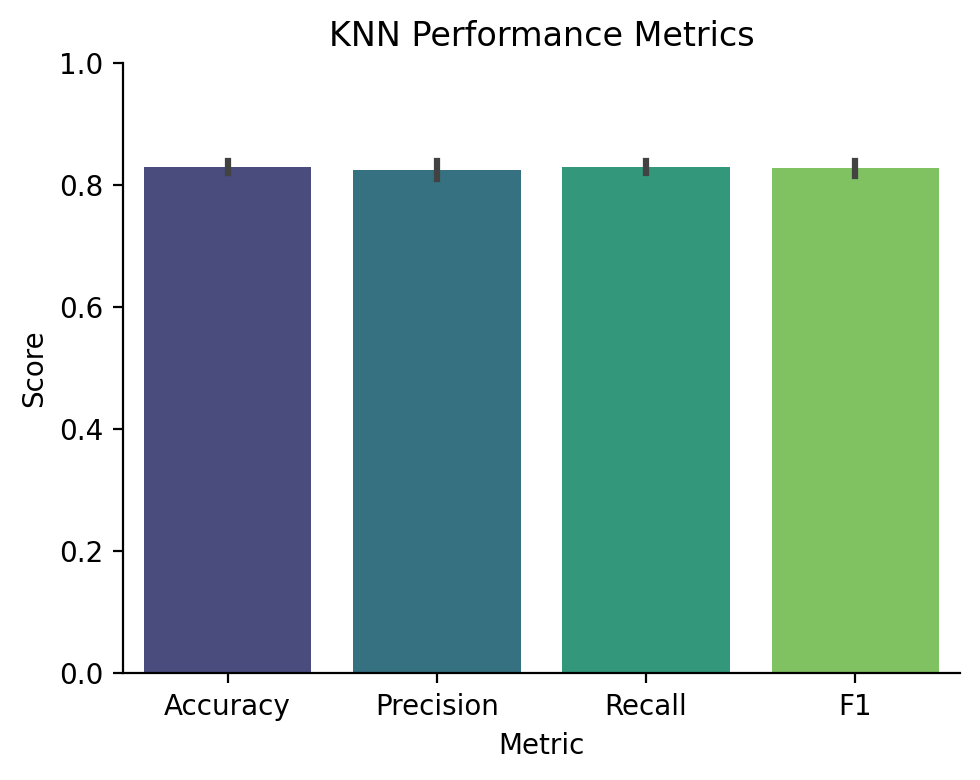

Naive Bayes: 0.1876 (std: 0.0180)


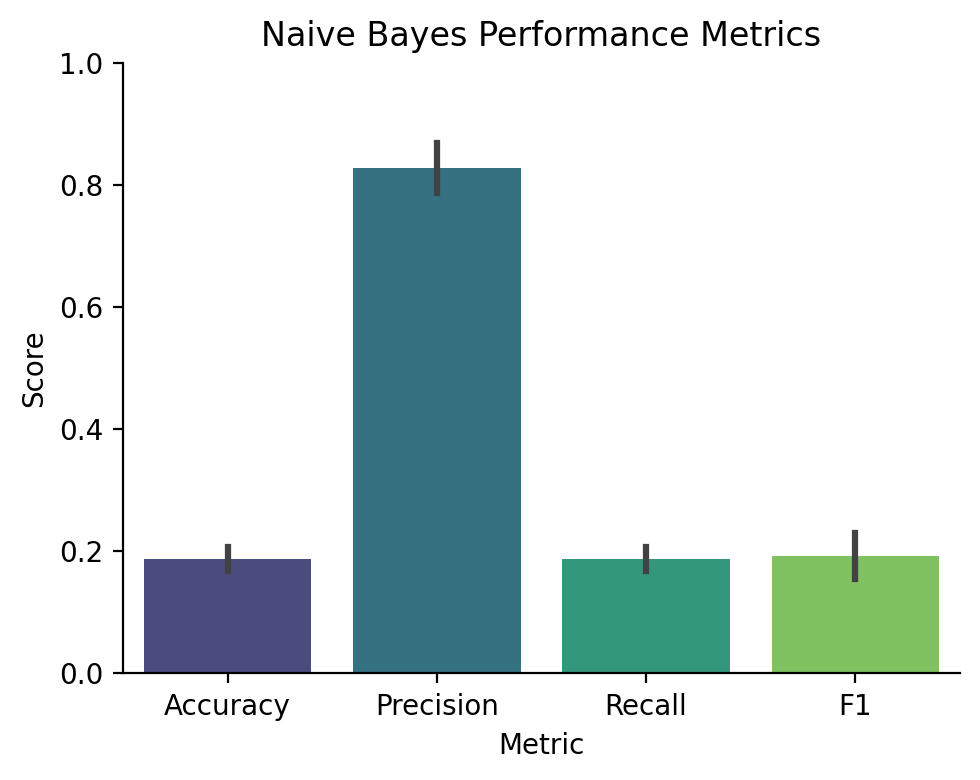

Decision Tree: 0.8900 (std: 0.0051)


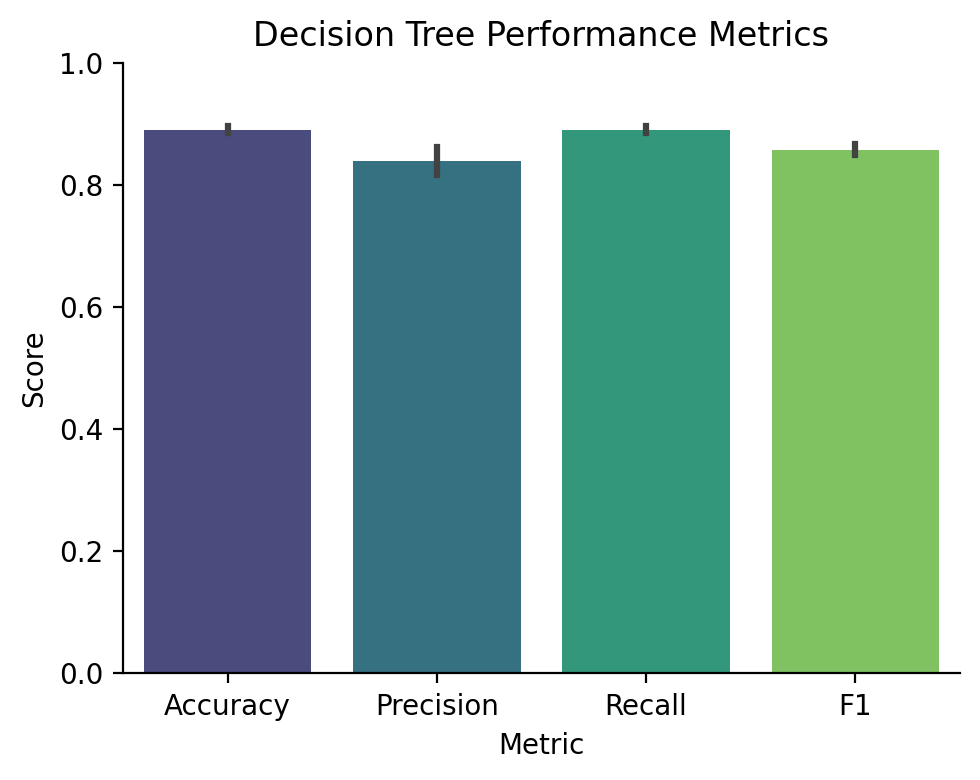

Random Forest: 0.9006 (std: 0.0012)


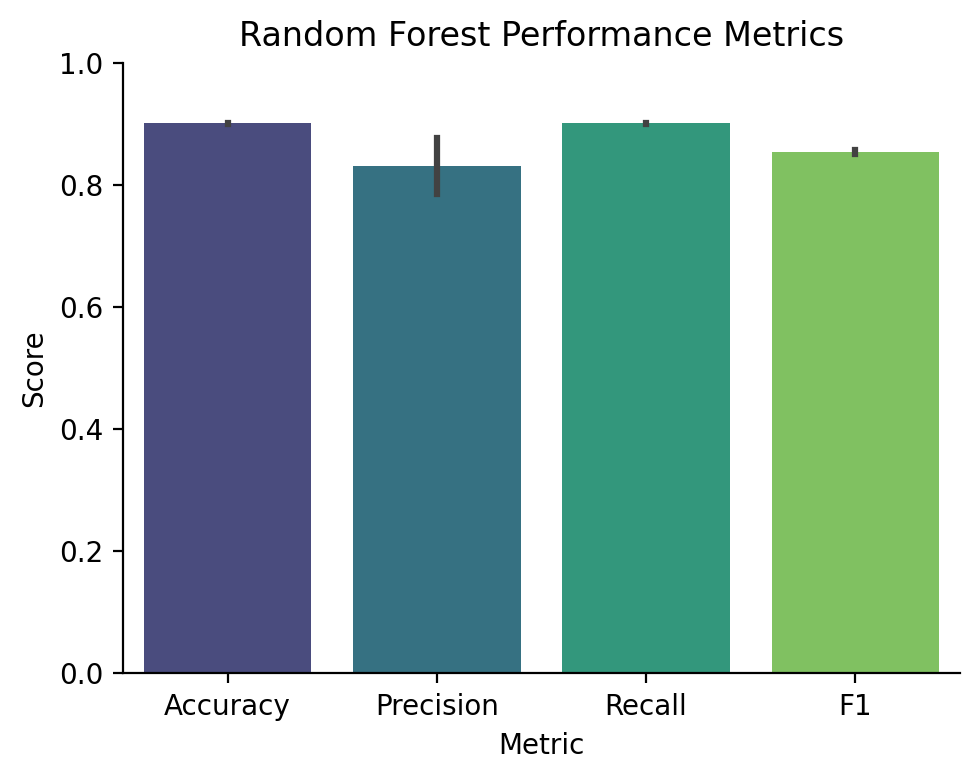

SVM (Linear): 0.8982 (std: 0.0024)


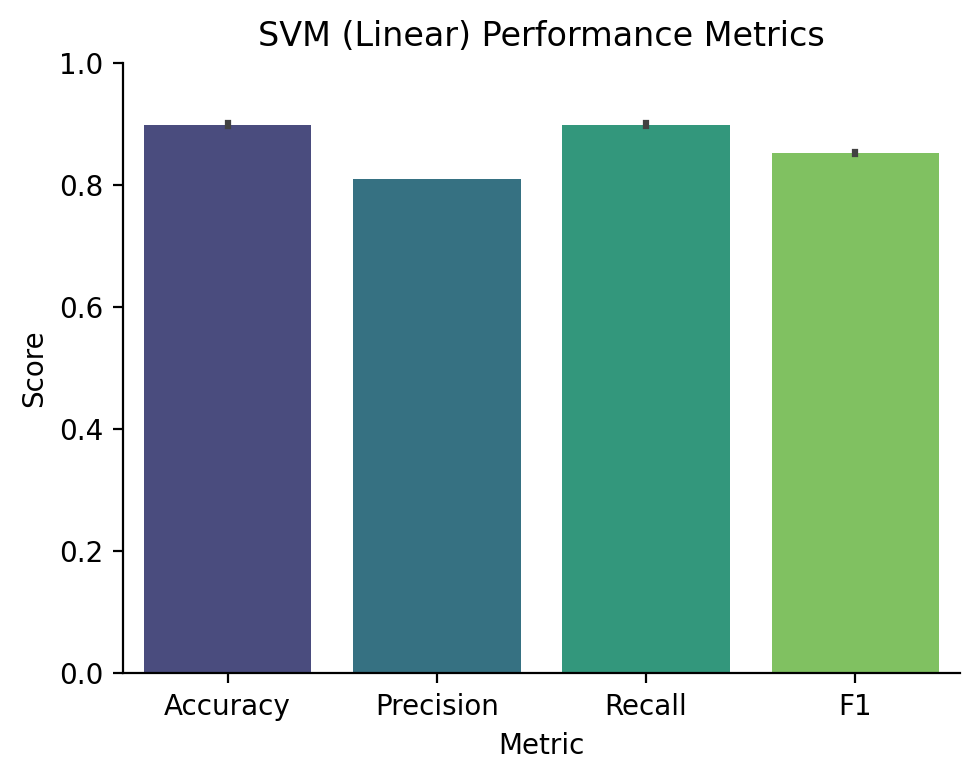

Neural Network: 0.8724 (std: 0.0196)


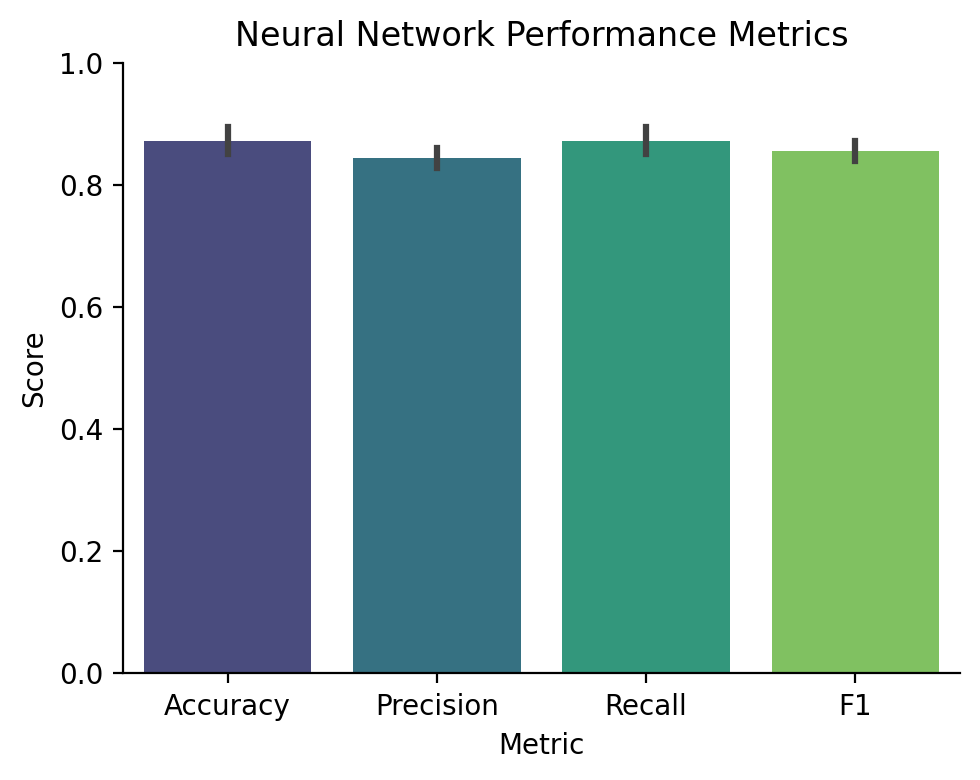

In [ ]:

print(f"Comparing models using with 5-Fold Cross-Validation...")
print("-" * 40)

for name, model in models.items():
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    cv_results = cross_validate(model, X, y, cv=kfold, scoring=metrics)

    acc_mean = cv_results['test_accuracy'].mean()
    acc_std = cv_results['test_accuracy'].std()
    print(f"{name}: {acc_mean:.4f} (std: {acc_std:.4f})")

    draw_metrics = {
      'Metric': ['Accuracy', 'Precision', 'Recall', 'F1'],
      'Score': [
          cv_results['test_accuracy'],
          cv_results['test_precision'],
          cv_results['test_recall'],
          cv_results['test_f1']
      ]
    }

    metrics_df = pd.DataFrame(draw_metrics)

    metrics_df = metrics_df.explode('Score', ignore_index=True)
    metrics_df['Score'] = metrics_df['Score'].astype(float)

    plt.figure(figsize=(5,4), dpi=200)
    sns.barplot(data=metrics_df, x='Metric', hue="Metric", y='Score', errorbar='sd', palette='viridis')
    plt.title(f"{name} Performance Metrics")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    sns.despine()
    plt.tight_layout()
    plt.show()
